# **1. Perkenalan Dataset**

Dataset yang digunakan adalah **Indonesian Abusive and Hate Speech Twitter Text** yang bersumber dari Kaggle ([link dataset](https://www.kaggle.com/datasets/ilhamfp31/indonesian-abusive-and-hate-speech-twitter-text)).

Dataset ini merupakan kumpulan tweet berbahasa Indonesia yang telah dianotasi secara manual untuk mendeteksi ujaran kebencian (*hate speech*) dan bahasa kasar (*abusive language*). Dataset terdiri dari tiga file utama:

1. **`data.csv`** — Dataset utama berisi tweet beserta label multi-kelas:
   - `Tweet`: teks tweet
   - `HS`: label hate speech (1 = ya, 0 = tidak)
   - `Abusive`: label bahasa kasar
   - `HS_Weak`, `HS_Moderate`, `HS_Strong`: tingkat keparahan hate speech
   - `HS_Individual`, `HS_Group`: target hate speech
   - `HS_Religion`, `HS_Race`, `HS_Physical`, `HS_Gender`, `HS_Other`: kategori hate speech
2. **`new_kamusalay.csv`** — Kamus normalisasi kata tidak baku/slang ke kata baku Bahasa Indonesia.

3. **`abusive.csv`** — Daftar leksikon kata kasar.

**Task:** Klasifikasi biner — memprediksi apakah sebuah tweet mengandung hate speech (`HS` = 1) atau tidak (`HS` = 0).

# **2. Import Library**

In [37]:
!pip install nltk scikit-learn pandas numpy matplotlib seaborn wordcloud

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# Visualisasi teks
from wordcloud import WordCloud

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

print('Semua library berhasil diimport!')

Semua library berhasil diimport!


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# **3. Memuat Dataset**

In [38]:
# Load dataset utama
df = pd.read_csv('data.csv', encoding='ISO-8859-1')

# Load kamus normalisasi (kamusalay)
kamusalay_df = pd.read_csv('new_kamusalay.csv',
                            encoding='ISO-8859-1',
                            header=None,
                            names=['slang', 'formal'])

# Load leksikon kata kasar
abusive_df = pd.read_csv('abusive.csv', encoding='ISO-8859-1')

print('=== Dataset Utama ===')
print(f'Jumlah baris: {df.shape[0]}')
print(f'Jumlah kolom: {df.shape[1]}')
print()
print('=== Kamus Kamusalay ===')
print(f'Jumlah entri: {kamusalay_df.shape[0]}')
print()
print('=== Leksikon Abusive ===')
print(f'Jumlah kata kasar: {abusive_df.shape[0]}')

=== Dataset Utama ===
Jumlah baris: 13169
Jumlah kolom: 13

=== Kamus Kamusalay ===
Jumlah entri: 15167

=== Leksikon Abusive ===
Jumlah kata kasar: 125


In [39]:
# Tampilkan beberapa baris pertama
print('=== 5 Baris Pertama Dataset ===')
df.head()

=== 5 Baris Pertama Dataset ===


,Tweet,HS,Abusive,HS_Individual,HS_Group,HS_Religion,HS_Race,HS_Physical,HS_Gender,HS_Other,HS_Weak,HS_Moderate,HS_Strong
0,- disaat semua cowok berusaha melacak perhatia...,1,1,1,0,0,0,0,0,1,1,0,0
1,RT USER: USER siapa yang telat ngasih tau elu?...,0,1,0,0,0,0,0,0,0,0,0,0
2,"41. Kadang aku berfikir, kenapa aku tetap perc...",0,0,0,0,0,0,0,0,0,0,0,0
3,USER USER AKU ITU AKU\n\nKU TAU MATAMU SIPIT T...,0,0,0,0,0,0,0,0,0,0,0,0
4,USER USER Kaum cebong kapir udah keliatan dong...,1,1,0,1,1,0,0,0,0,0,1,0


**Struktur dataset**

In [40]:
print('=== Informasi Dataset ===')
df.info()

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13169 entries, 0 to 13168
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Tweet          13169 non-null  object
 1   HS             13169 non-null  int64 
 2   Abusive        13169 non-null  int64 
 3   HS_Individual  13169 non-null  int64 
 4   HS_Group       13169 non-null  int64 
 5   HS_Religion    13169 non-null  int64 
 6   HS_Race        13169 non-null  int64 
 7   HS_Physical    13169 non-null  int64 
 8   HS_Gender      13169 non-null  int64 
 9   HS_Other       13169 non-null  int64 
 10  HS_Weak        13169 non-null  int64 
 11  HS_Moderate    13169 non-null  int64 
 12  HS_Strong      13169 non-null  int64 
dtypes: int64(12), object(1)
memory usage: 1.3+ MB


**Statistik Deskriptif**

In [41]:
print('=== Statistik Deskriptif ===')
df.describe()

=== Statistik Deskriptif ===


,HS,Abusive,HS_Individual,HS_Group,HS_Religion,HS_Race,HS_Physical,HS_Gender,HS_Other,HS_Weak,HS_Moderate,HS_Strong
count,13169.000000,13169.000000,13169.000000,13169.000000,13169.000000,13169.000000,13169.000000,13169.000000,13169.000000,13169.000000,13169.000000,13169.000000
mean,0.422280,0.382945,0.271471,0.150809,0.060217,0.042980,0.024527,0.023236,0.284000,0.256891,0.129471,0.035918
std,0.493941,0.486123,0.444735,0.357876,0.237898,0.202819,0.154685,0.150659,0.450954,0.436935,0.335733,0.186092
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# **4. Exploratory Data Analysis (EDA)**

**Distribusi Label Utama (HS)**

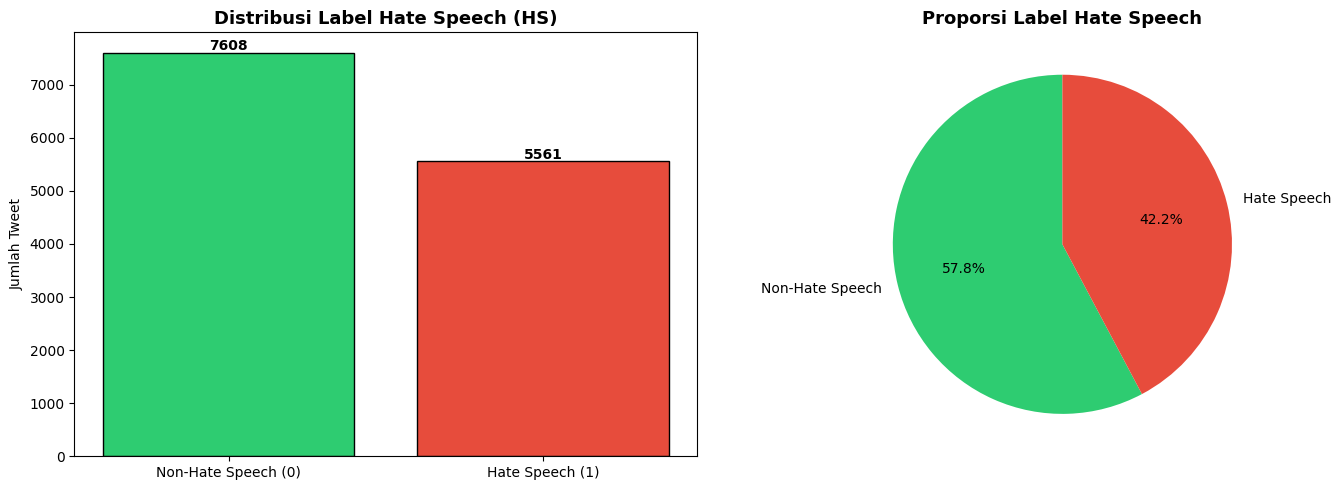

Distribusi label:
HS
0    7608
1    5561
Name: count, dtype: int64


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
hs_counts = df['HS'].value_counts()
axes[0].bar(['Non-Hate Speech (0)', 'Hate Speech (1)'],
            hs_counts.values,
            color=['#2ecc71', '#e74c3c'],
            edgecolor='black')
axes[0].set_title('Distribusi Label Hate Speech (HS)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Tweet')
for i, v in enumerate(hs_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(hs_counts.values,
            labels=['Non-Hate Speech', 'Hate Speech'],
            autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'],
            startangle=90)
axes[1].set_title('Proporsi Label Hate Speech', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Distribusi label:\n{hs_counts}')

**Distribusi Label Abusive**

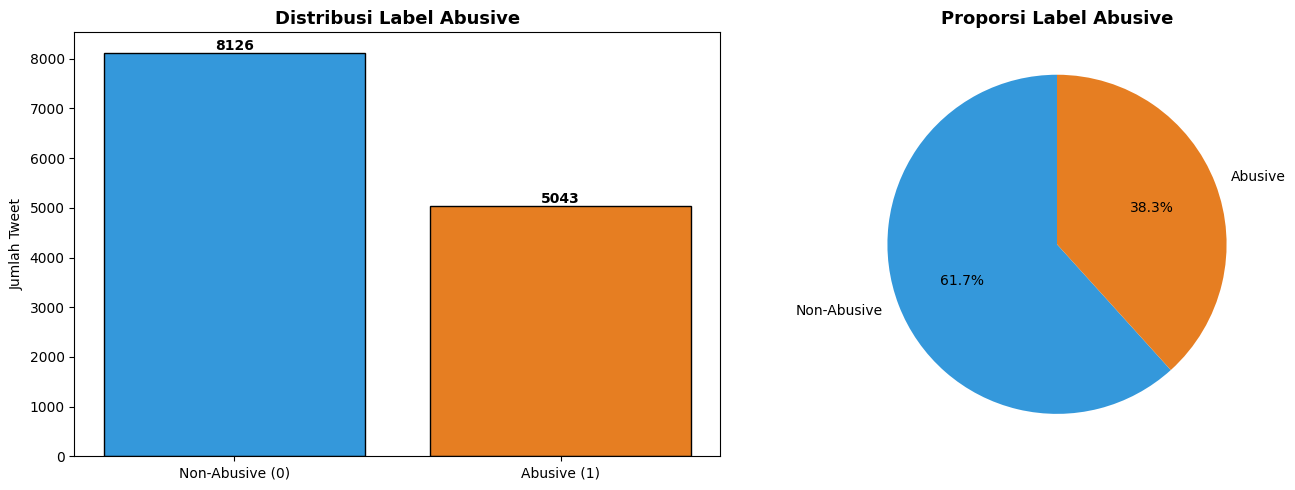

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

abusive_counts = df['Abusive'].value_counts()
axes[0].bar(['Non-Abusive (0)', 'Abusive (1)'],
            abusive_counts.values,
            color=['#3498db', '#e67e22'],
            edgecolor='black')
axes[0].set_title('Distribusi Label Abusive', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Tweet')
for i, v in enumerate(abusive_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(abusive_counts.values,
            labels=['Non-Abusive', 'Abusive'],
            autopct='%1.1f%%',
            colors=['#3498db', '#e67e22'],
            startangle=90)
axes[1].set_title('Proporsi Label Abusive', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_abusive_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Distribusi Kategori Hate Speec**

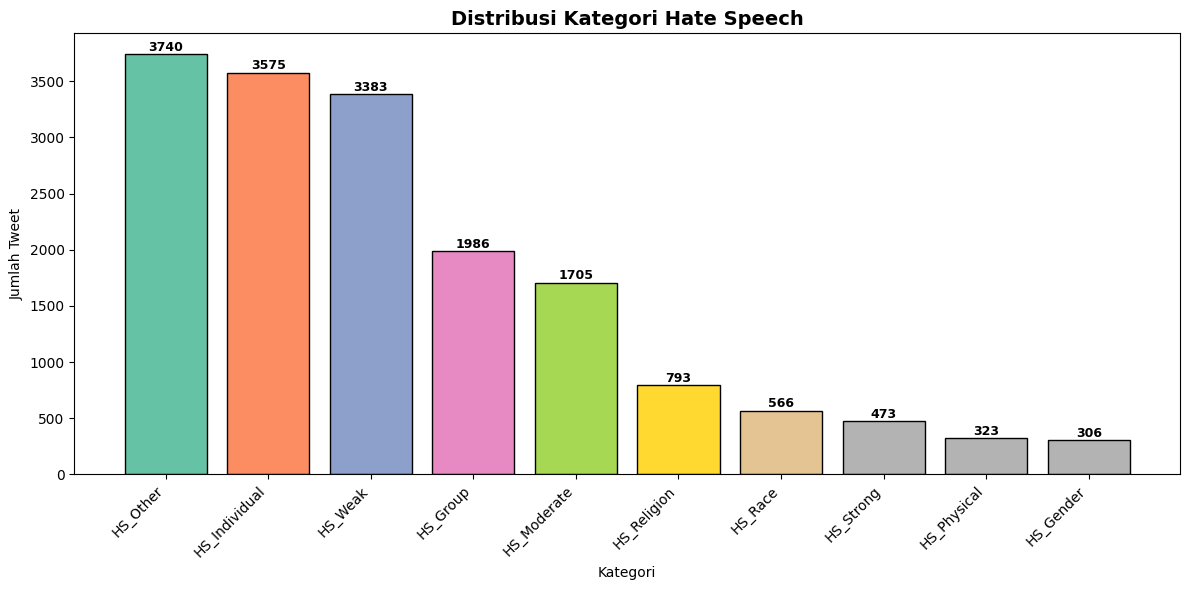

In [44]:
hs_categories = ['HS_Weak', 'HS_Moderate', 'HS_Strong',
                 'HS_Individual', 'HS_Group',
                 'HS_Religion', 'HS_Race', 'HS_Physical',
                 'HS_Gender', 'HS_Other']

cat_sums = df[hs_categories].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(cat_sums.index, cat_sums.values,
               color=plt.cm.Set2(range(len(cat_sums))),
               edgecolor='black')
plt.title('Distribusi Kategori Hate Speech', fontsize=14, fontweight='bold')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Tweet')
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars, cat_sums.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             str(val), ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_hs_categories.png', dpi=150, bbox_inches='tight')
plt.show()

**Analisis Panjang Tweet**

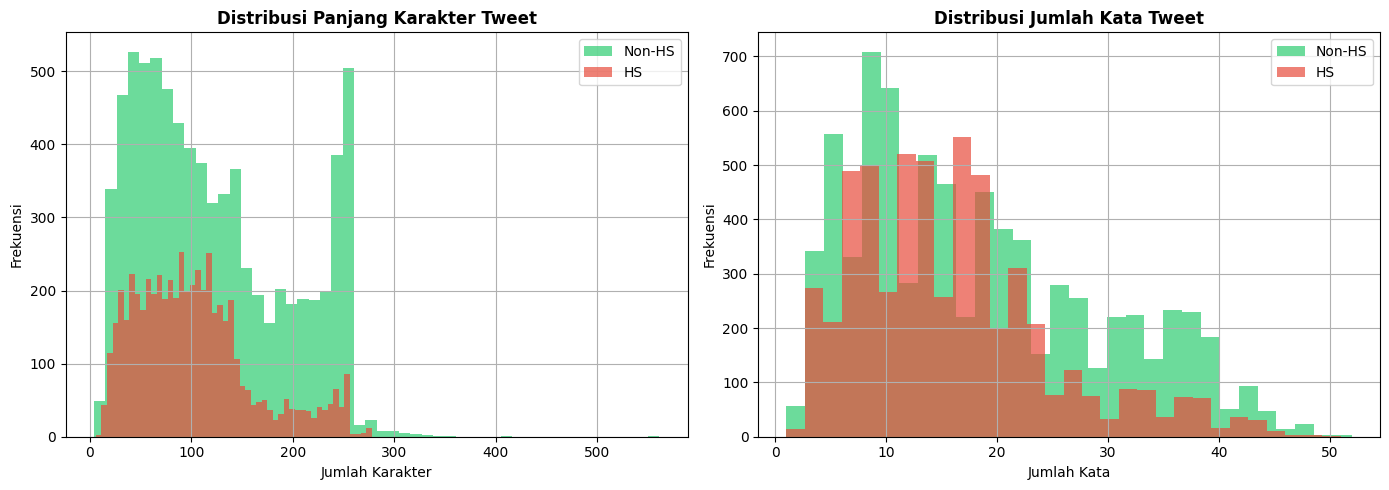

=== Statistik Panjang Tweet ===
     count        mean        std  min   25%    50%    75%    max
HS                                                               
0   7608.0  122.998817  74.958891  4.0  60.0  107.5  183.0  561.0
1   5561.0  102.168855  57.984596  6.0  58.0   94.0  131.0  278.0


In [45]:
df['tweet_length'] = df['Tweet'].astype(str).apply(len)
df['word_count'] = df['Tweet'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi panjang karakter
df[df['HS']==0]['tweet_length'].hist(bins=50, ax=axes[0], alpha=0.7, label='Non-HS', color='#2ecc71')
df[df['HS']==1]['tweet_length'].hist(bins=50, ax=axes[0], alpha=0.7, label='HS', color='#e74c3c')
axes[0].set_title('Distribusi Panjang Karakter Tweet', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jumlah Karakter')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Distribusi jumlah kata
df[df['HS']==0]['word_count'].hist(bins=30, ax=axes[1], alpha=0.7, label='Non-HS', color='#2ecc71')
df[df['HS']==1]['word_count'].hist(bins=30, ax=axes[1], alpha=0.7, label='HS', color='#e74c3c')
axes[1].set_title('Distribusi Jumlah Kata Tweet', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jumlah Kata')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_tweet_length.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Statistik Panjang Tweet ===')
print(df.groupby('HS')['tweet_length'].describe())

**Missing Values**

=== Cek Missing Values ===
Tweet            0
HS               0
Abusive          0
HS_Individual    0
HS_Group         0
HS_Religion      0
HS_Race          0
HS_Physical      0
HS_Gender        0
HS_Other         0
HS_Weak          0
HS_Moderate      0
HS_Strong        0
tweet_length     0
word_count       0
dtype: int64


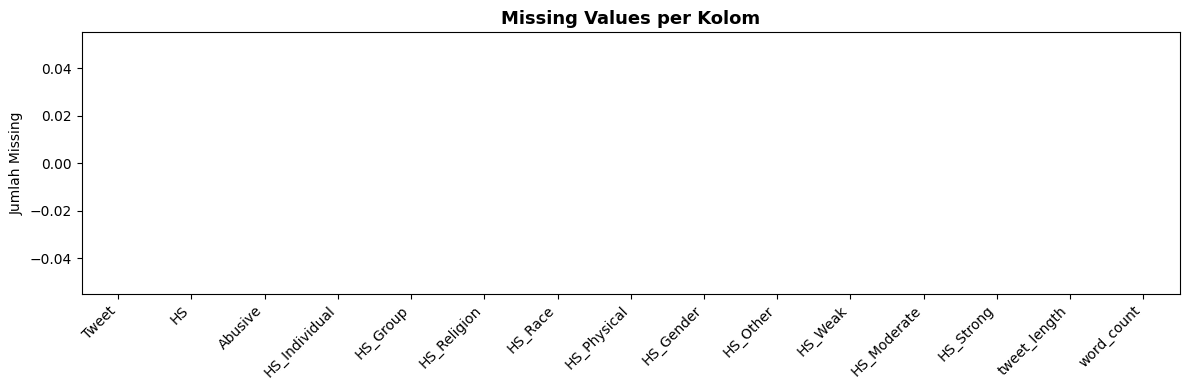

In [46]:
print('=== Cek Missing Values ===')
missing = df.isnull().sum()
print(missing)

plt.figure(figsize=(12, 4))
missing.plot(kind='bar', color='#e74c3c' if missing.sum() > 0 else '#2ecc71')
plt.title('Missing Values per Kolom', fontsize=13, fontweight='bold')
plt.ylabel('Jumlah Missing')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('eda_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

**Cek Duplikasi**

In [47]:
n_dup = df.duplicated(subset=['Tweet']).sum()
print(f'Jumlah tweet duplikat: {n_dup}')
print(f'Persentase duplikat: {n_dup/len(df)*100:.2f}%')

Jumlah tweet duplikat: 146
Persentase duplikat: 1.11%


**WordCloud: Hate Speech vs Non-Hate Speech**

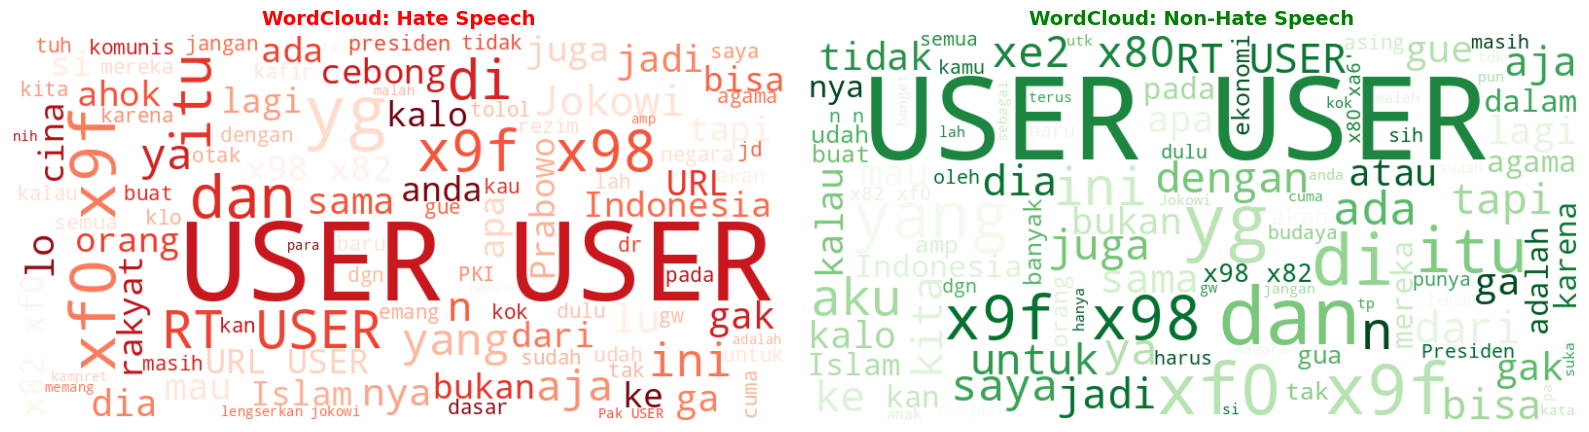

In [48]:
hs_text = ' '.join(df[df['HS']==1]['Tweet'].astype(str).tolist())
non_hs_text = ' '.join(df[df['HS']==0]['Tweet'].astype(str).tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_hs = WordCloud(width=800, height=400, background_color='white',
                  colormap='Reds', max_words=100).generate(hs_text)
axes[0].imshow(wc_hs, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('WordCloud: Hate Speech', fontsize=14, fontweight='bold', color='red')

wc_non = WordCloud(width=800, height=400, background_color='white',
                   colormap='Greens', max_words=100).generate(non_hs_text)
axes[1].imshow(wc_non, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('WordCloud: Non-Hate Speech', fontsize=14, fontweight='bold', color='green')

plt.tight_layout()
plt.savefig('eda_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

**Korelasi antar Label**

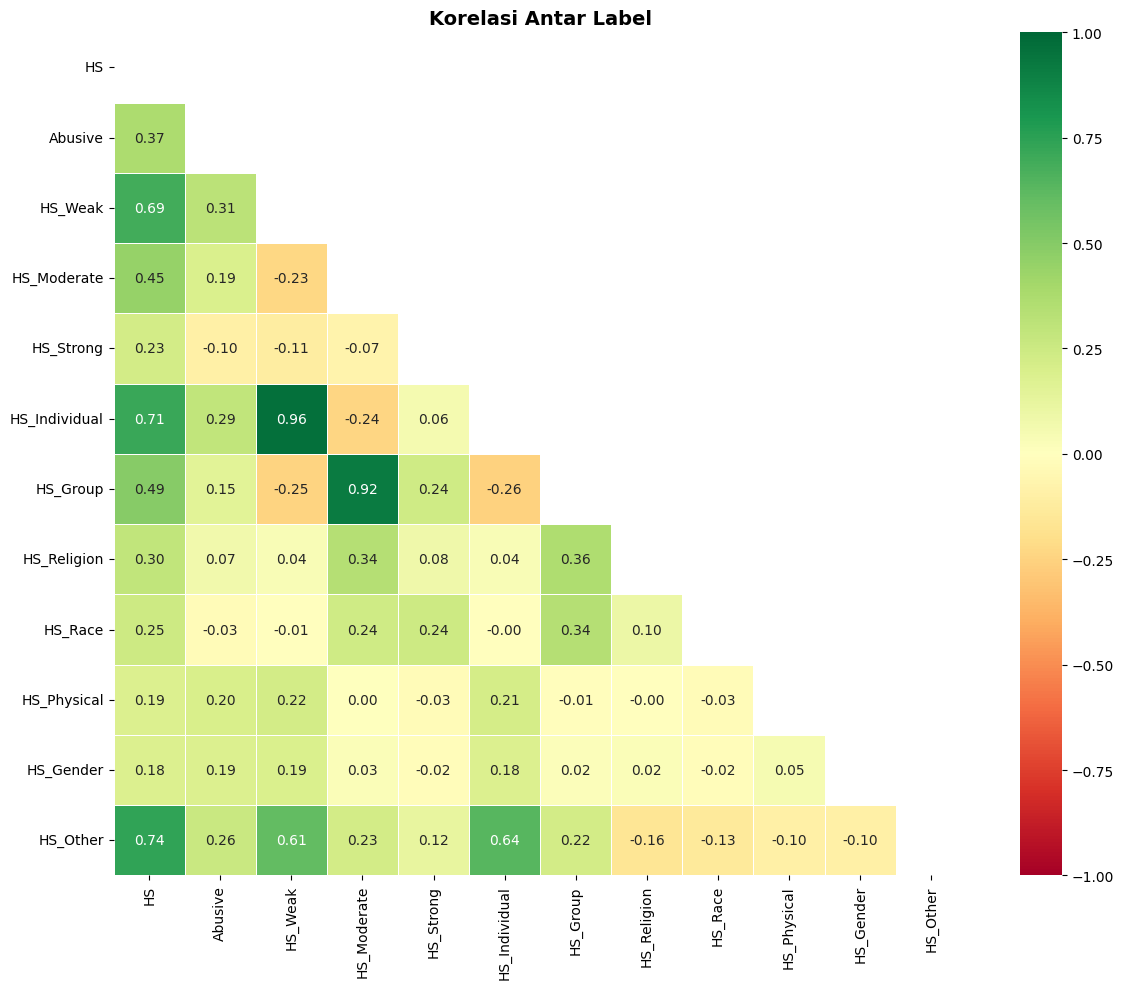

In [49]:
label_cols = ['HS', 'Abusive', 'HS_Weak', 'HS_Moderate', 'HS_Strong',
              'HS_Individual', 'HS_Group', 'HS_Religion', 'HS_Race',
              'HS_Physical', 'HS_Gender', 'HS_Other']

plt.figure(figsize=(12, 10))
corr_matrix = df[label_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Korelasi Antar Label', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# **5. Data Preprocessing**

Tahapan preprocessing untuk data teks NLP ini meliputi:
1. Penanganan missing values dan duplikasi
2. Lowercasing
3. Penghapusan mention, URL, angka, dan karakter khusus
4. Normalisasi kata slang/tidak baku menggunakan `new_kamusalay.csv`
5. Tokenisasi
6. Stopword removal (Bahasa Indonesia)
7. Feature extraction menggunakan TF-IDF
8. Split data train/test

**Hapus Missing Values dan Duplikasi**

In [50]:
print(f'Jumlah data awal: {len(df)}')

# Hapus baris dengan Tweet kosong
df = df.dropna(subset=['Tweet'])

# Hapus duplikat berdasarkan kolom Tweet
df = df.drop_duplicates(subset=['Tweet'])
df = df.reset_index(drop=True)

print(f'Jumlah data setelah hapus missing & duplikat: {len(df)}')

Jumlah data awal: 13169
Jumlah data setelah hapus missing & duplikat: 13023


**Buat Kamus Normalisasi dari Kamusalay**

In [51]:
kamusalay_dict = dict(zip(kamusalay_df['slang'], kamusalay_df['formal']))
print(f'Jumlah kata dalam kamus normalisasi: {len(kamusalay_dict)}')
print('Contoh normalisasi:')
for k, v in list(kamusalay_dict.items())[:5]:
    print(f'  {k} -> {v}')

Jumlah kata dalam kamus normalisasi: 15167
Contoh normalisasi:
  anakjakartaasikasik -> anak jakarta asyik asyik
  pakcikdahtua -> pak cik sudah tua
  pakcikmudalagi -> pak cik muda lagi
  t3tapjokowi -> tetap jokowi
  3x -> tiga kali


**Fungsi-fungsi Preprocessing**

In [52]:
def lowercase_text(text):
    """Mengubah teks menjadi huruf kecil."""
    return str(text).lower()

def remove_noise(text):
    """Menghapus mention, URL, hashtag, angka, tanda baca, dan karakter khusus."""
    text = re.sub(r'@[\w]+', 'USER', text)       # Ganti mention dengan USER
    text = re.sub(r'http\S+|www\S+', 'URL', text) # Ganti URL
    text = re.sub(r'#[\w]+', '', text)             # Hapus hashtag
    text = re.sub(r'\d+', '', text)                # Hapus angka
    text = re.sub(r'[^\w\s]', ' ', text)           # Hapus tanda baca
    text = re.sub(r'_', ' ', text)                 # Ganti underscore
    text = re.sub(r'\s+', ' ', text).strip()       # Hapus spasi berlebih
    return text

def normalize_slang(text, kamus):
    """Normalisasi kata slang menggunakan kamus kamusalay."""
    words = text.split()
    normalized = [kamus.get(word, word) for word in words]
    return ' '.join(normalized)

def remove_stopwords(text):
    """Menghapus stopwords Bahasa Indonesia."""
    stop_words = set(stopwords.words('indonesian'))
    additional_stopwords = {'user', 'url', 'rt', 'yg', 'dgn', 'nya', 'jg'}
    stop_words.update(additional_stopwords)
    tokens = word_tokenize(text)
    filtered = [word for word in tokens
                if word not in stop_words and len(word) > 1]
    return ' '.join(filtered)

def preprocess_text(text, kamus):
    """Pipeline preprocessing lengkap."""
    text = lowercase_text(text)
    text = remove_noise(text)
    text = normalize_slang(text, kamus)
    text = remove_stopwords(text)
    return text

print('Fungsi preprocessing siap!')

Fungsi preprocessing siap!


**Penerapan Preprocessing**

In [53]:
print('Memulai preprocessing teks...')

df['Tweet_clean'] = df['Tweet'].apply(
    lambda x: preprocess_text(x, kamusalay_dict)
)

print('Preprocessing selesai!')
print()
print('=== Contoh Hasil Preprocessing ===')
for i in range(3):
    print(f'Asli   : {df["Tweet"].iloc[i]}')
    print(f'Bersih : {df["Tweet_clean"].iloc[i]}')
    print('-' * 60)

Memulai preprocessing teks...
Preprocessing selesai!

=== Contoh Hasil Preprocessing ===
Asli   : - disaat semua cowok berusaha melacak perhatian gue. loe lantas remehkan perhatian yg gue kasih khusus ke elo. basic elo cowok bego ! ! !'
Bersih : cowok berusaha melacak perhatian gue lantas remehkan perhatian gue kasih khusus basic cowok bego
------------------------------------------------------------
Asli   : RT USER: USER siapa yang telat ngasih tau elu?edan sarap gue bergaul dengan cigax jifla calis sama siapa noh licew juga'
Bersih : pengguna pengguna telat tau edan sarap gue bergaul cigax jifla calis licew
------------------------------------------------------------
Asli   : 41. Kadang aku berfikir, kenapa aku tetap percaya pada Tuhan padahal aku selalu jatuh berkali-kali. Kadang aku merasa Tuhan itu ninggalkan aku sendirian. Ketika orangtuaku berencana berpisah, ketika kakakku lebih memilih jadi Kristen. Ketika aku anak ter
Bersih : kadang berpikir percaya tuhan jatuh berkali kali

**Hapus Baris Kosong Setelah Preprocessing**

In [54]:
df = df[df['Tweet_clean'].str.strip() != '']
df = df.reset_index(drop=True)
print(f'Jumlah data setelah hapus tweet kosong pasca preprocessing: {len(df)}')

Jumlah data setelah hapus tweet kosong pasca preprocessing: 13017


**Feature Extraction: TF-IDF**

In [55]:
X = df['Tweet_clean']
y = df['HS']

# Split train/test (80:20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Ukuran data train: {X_train.shape[0]}')
print(f'Ukuran data test : {X_test.shape[0]}')
print(f'Distribusi label train:\n{y_train.value_counts()}')

Ukuran data train: 10413
Ukuran data test : 2604
Distribusi label train:
HS
0    6013
1    4400
Name: count, dtype: int64


**TF-IDF Vectorization**

In [56]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),  # Unigram + Bigram
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f'Shape TF-IDF train: {X_train_tfidf.shape}')
print(f'Shape TF-IDF test : {X_test_tfidf.shape}')

Shape TF-IDF train: (10413, 10000)
Shape TF-IDF test : (2604, 10000)


**Simpan Dataset Hasil Preprocessing**

In [57]:
import scipy.sparse as sp
import joblib
import os

os.makedirs('data_preprocessing', exist_ok=True)

# Simpan dataframe bersih
df[['Tweet_clean', 'HS', 'Abusive', 'HS_Weak', 'HS_Moderate', 'HS_Strong',
    'HS_Individual', 'HS_Group', 'HS_Religion', 'HS_Race',
    'HS_Physical', 'HS_Gender', 'HS_Other']].to_csv(
    'data_preprocessing/hate_speech_preprocessed.csv', index=False
)

# Simpan train/test split
X_train.to_csv('data_preprocessing/X_train.csv', index=False, header=['Tweet_clean'])
X_test.to_csv('data_preprocessing/X_test.csv', index=False, header=['Tweet_clean'])
y_train.to_csv('data_preprocessing/y_train.csv', index=False, header=['HS'])
y_test.to_csv('data_preprocessing/y_test.csv', index=False, header=['HS'])

# Simpan TF-IDF matrix (sparse)
sp.save_npz('data_preprocessing/X_train_tfidf.npz', X_train_tfidf)
sp.save_npz('data_preprocessing/X_test_tfidf.npz', X_test_tfidf)

# Simpan TF-IDF vectorizer
joblib.dump(tfidf, 'data_preprocessing/tfidf_vectorizer.pkl')

print('Dataset preprocessing berhasil disimpan di folder data_preprocessing/')
print('File yang disimpan:')
for f in os.listdir('data_preprocessing'):
    print(f'  - {f}')

Dataset preprocessing berhasil disimpan di folder data_preprocessing/
File yang disimpan:
  - hate_speech_preprocessed.csv
  - y_test.csv
  - X_test.csv
  - X_train.csv
  - tfidf_vectorizer.pkl
  - X_test_tfidf.npz
  - X_train_tfidf.npz
  - y_train.csv


In [58]:
print('=' * 50)
print('RINGKASAN PREPROCESSING')
print('=' * 50)
print(f'Total data final       : {len(df)}')
print(f'Fitur TF-IDF (train)   : {X_train_tfidf.shape}')
print(f'Fitur TF-IDF (test)    : {X_test_tfidf.shape}')
print(f'Distribusi label (HS=1): {y.mean()*100:.1f}%')
print(f'Distribusi label (HS=0): {(1-y.mean())*100:.1f}%')
print('=' * 50)
print('Data siap untuk tahap pelatihan model!')

RINGKASAN PREPROCESSING
Total data final       : 13017
Fitur TF-IDF (train)   : (10413, 10000)
Fitur TF-IDF (test)    : (2604, 10000)
Distribusi label (HS=1): 42.3%
Distribusi label (HS=0): 57.7%
Data siap untuk tahap pelatihan model!
